# Customer Shopping Behavior Analysis

## Data Loading

In [2]:
import pandas as pd

df = pd.read_csv("../data/customer_shopping_behavior.csv")

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
df.shape

(3900, 18)

In [4]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

## Data Cleaning

In [6]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [7]:
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(
    lambda x: x.fillna(x.median())
)

In [8]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [9]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("(", "", regex=False)
df.columns = df.columns.str.replace(")", "", regex=False)
df.columns = df.columns.str.replace("usd", "", regex=False)
df.columns = df.columns.str.strip("_")

df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [10]:
labels = ["Young Adult", "Adult", "Middle-aged", "Senior"]

df["age_group"] = pd.qcut(
    df["age"],
    q=4,
    labels=labels
)

df[["age", "age_group"]].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [11]:
frequency_mapping = {
    "Weekly": 7,
    "Fortnightly": 14,
    "Bi-Weekly": 14,
    "Monthly": 30,
    "Quarterly": 90,
    "Every 3 Months": 90,
    "Annually": 365
}

df["purchase_frequency_days"] = df["frequency_of_purchases"].map(frequency_mapping)

df[["frequency_of_purchases", "purchase_frequency_days"]].head(10)

,frequency_of_purchases,purchase_frequency_days
0,Fortnightly,14
1,Fortnightly,14
2,Weekly,7
3,Weekly,7
4,Annually,365
5,Weekly,7
6,Quarterly,90
7,Weekly,7
8,Annually,365
9,Quarterly,90


In [12]:
(df["discount_applied"] == df["promo_code_used"]).all()

np.True_

In [13]:
df = df.drop("promo_code_used", axis=1)

In [14]:
df.to_csv("../data/customer_cleaned.csv", index=False)

## Exploratory Data Analysis (EDA)

In [15]:
df["purchase_amount"].sum()

np.int64(233081)

In [16]:
df["purchase_amount"].mean()

np.float64(59.76435897435898)

In [17]:
df["customer_id"].nunique()

3900

In [18]:
df.groupby("gender")["purchase_amount"].sum().sort_values(ascending=False)

gender
Male      157890
Female     75191
Name: purchase_amount, dtype: int64

In [19]:
df.groupby("category")["purchase_amount"].sum().sort_values(ascending=False)

category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: purchase_amount, dtype: int64

In [20]:
df.groupby("category")["review_rating"].mean().round(2)

category
Accessories    3.77
Clothing       3.72
Footwear       3.79
Outerwear      3.75
Name: review_rating, dtype: float64

In [21]:
df["item_purchased"].value_counts().head(10)

item_purchased
Blouse        171
Jewelry       171
Pants         171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Belt          161
Sunglasses    161
Coat          161
Name: count, dtype: int64

In [22]:
df.groupby("subscription_status")["purchase_amount"].agg(["count", "mean", "sum"])

,count,mean,sum
subscription_status,,,
No,2847,59.865121,170436
Yes,1053,59.491928,62645


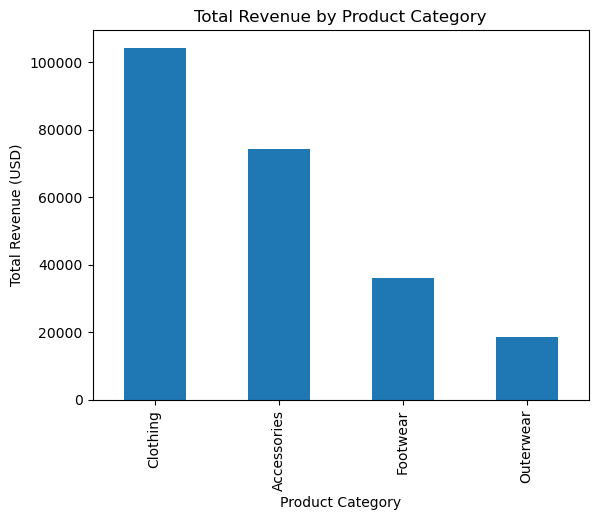

In [23]:
revenue_by_category = (
    df.groupby("category")["purchase_amount"].sum().sort_values(ascending=False)
)

revenue_by_category.plot(kind="bar", title="Total Revenue by Product Category")
import matplotlib.pyplot as plt

plt.ylabel("Total Revenue (USD)")
plt.xlabel("Product Category")  
plt.show()

In [24]:
df.to_csv("../data/customer_cleaned.csv", index=False)

## connect to SQL server

In [25]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

In [26]:
server = r"DESKTOP-V1JMRLS\SQLEXPRESS"
database = "customer_behavior"

driver = quote_plus ("ODBC Driver 17 for SQL Server")

engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}?driver={driver}&trusted_connection=yes"
)

In [27]:
df.to_sql(
    "customer",
    engine,
    if_exists="replace",
    index=False
)

c:\ProgramData\anaconda3\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


50

In [28]:
test = pd.read_sql("SELECT TOP 5 * FROM customer", engine)
test

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle-aged,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle-aged,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle-aged,365
